# Fake News Classification

A simple NLP pipeline for detecting fake news headlines, using multiple feature extraction methods and classifiers.

In [2]:
import os
import re
import warnings

import contractions
import fasttext
import fasttext.util
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch

from gensim.models import Word2Vec
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from transformers import BertTokenizer, BertModel

warnings.filterwarnings("ignore")

nltk.download("wordnet", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("omw-1.4", quiet=True)

RANDOM_STATE = 96

/Users/rmei/repos/ih-fake-news-detector/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. EDA

In [3]:
df_train: pd.DataFrame = pd.read_csv(
    "data/raw/training_data.csv",
    header=None,
    sep='\t',
    names=['is_real', 'text'],
    dtype={'is_real': np.int8}
)[['text', 'is_real']].sample(frac=1, random_state=96).reset_index(drop=True)

df_test: pd.DataFrame = pd.read_csv(
    "data/raw/testing_data.csv",
    header=None,
    sep='\t',
    names=['is_real', 'text']
)[['text', 'is_real']].sample(frac=1, random_state=96).reset_index(drop=True)

print(f"Training set: {df_train.shape}")
print(f"Test set:     {df_test.shape}")

Training set: (34152, 2)
Test set:     (9984, 2)


In [4]:
print("DF TRAIN")
df_train.info()
print("\nDF TEST")
df_test.info()
print("\nSAMPLE")
df_train.head()

DF TRAIN
<class 'pandas.DataFrame'>
RangeIndex: 34152 entries, 0 to 34151
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   text     34152 non-null  str  
 1   is_real  34152 non-null  int8 
dtypes: int8(1), str(1)
memory usage: 300.3 KB

DF TEST
<class 'pandas.DataFrame'>
RangeIndex: 9984 entries, 0 to 9983
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   text     9984 non-null   str  
 1   is_real  9984 non-null   str  
dtypes: str(2)
memory usage: 156.1 KB

SAMPLE


,text,is_real
0,white house: more obama regulation rollbacks c...,1
1,renzi congratulates trump\tsays italy friendsh...,1
2,mccain f*cked over senate republicans on trump...,0
3,breaking: aclj files lawsuit against obama‚s c...,0
4,heartbreaking: this democratic senator just tw...,0


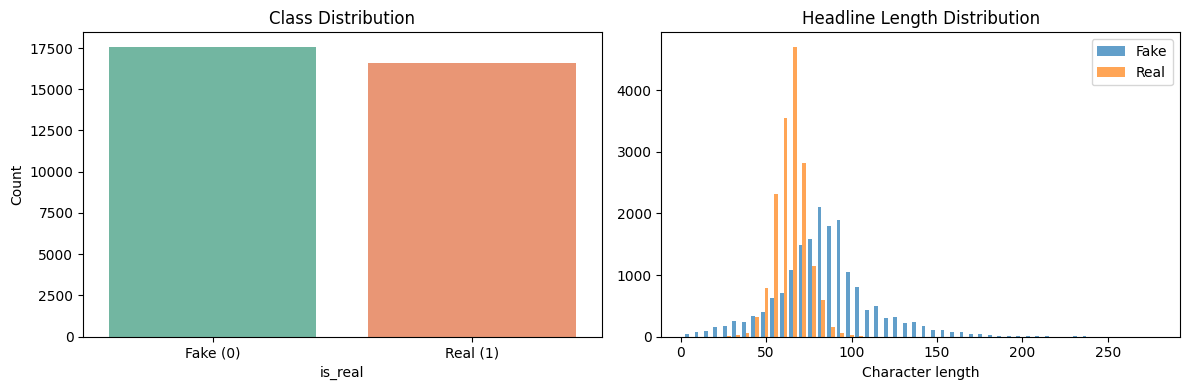

In [5]:
_, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df_train, x="is_real", ax=axes[0], palette="Set2")
axes[0].set_title("Class Distribution")
axes[0].set_xticklabels(["Fake (0)", "Real (1)"])
axes[0].set_ylabel("Count")

text_lengths = df_train.text.str.len()
axes[1].hist(
    [text_lengths[df_train.is_real == 0], text_lengths[df_train.is_real == 1]],
    bins=50, label=["Fake", "Real"], alpha=0.7
)
axes[1].set_title("Headline Length Distribution")
axes[1].set_xlabel("Character length")
axes[1].legend()

plt.tight_layout()
plt.show()

## 2. Text Preprocessing

Use **lemmatization** to produce valid words and preserve semantic meaning for downstream models.

The pipeline normalizes mojibake characters, expands contractions before removing punctuation, and applies standard NLP cleaning steps (except lowercase, since the data is already lower-cased).

In [6]:
STOP_WORDS: list[str] = stopwords.words("english")
lemmatizer: WordNetLemmatizer = WordNetLemmatizer()

def preprocess_text(text) -> str:
    # Replace broken characters
    text = text.replace("‚î", " - ")
    text = text.replace("‚", "'")
    text = text.replace("√©", "e")
    text = text.replace("¬†", " ")
    text = text.replace("√≠­", "i")
    text = text.replace("√º", "u")

    # Country normalization
    text = text.replace("u.s.a.", "usa")
    text = text.replace("u.s.", "usa")
    text = text.replace("u.k.", "uk")

    text = contractions.fix(text) # expand contractions (don't -> do not)
    text = re.sub(r"[^a-z0-9]+", " ", text).strip() # keep only alphanumeric and spaces

    tokens = text.split()
    lemma_tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in STOP_WORDS]

    return " ".join(lemma_tokens)

In [7]:
df_train["clean_text"] = df_train.text.apply(preprocess_text)
df_test["clean_text"] = df_test.text.apply(preprocess_text)

In [8]:
for _, row in df_train.sample(n=5).iterrows():
    print(f"BEFORE: {row.text}")
    print(f"AFTER:  {row.clean_text}")
    print("-" * 50)

BEFORE: rubio‚s campaign just committed suicide in this state for good reasons (video)
AFTER:  rubio campaign committed suicide state good reason video
--------------------------------------------------
BEFORE: global finance leaders find a more temperate trump in washington
AFTER:  global finance leader find temperate trump washington
--------------------------------------------------
BEFORE: senator warren calls on fed to remove wells fargo board members
AFTER:  senator warren call fed remove well fargo board member
--------------------------------------------------
BEFORE: caught on camera: devastating moment 2100 people find out job outsourced (video)
AFTER:  caught camera devastating moment 2100 people find job outsourced video
--------------------------------------------------
BEFORE: zimbabwe's mugabe	coup chief meet with smiles and handshakes
AFTER:  zimbabwe mugabe coup chief meet smile handshake
--------------------------------------------------


In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    df_train.clean_text,
    df_train.is_real,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_train.is_real
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Val:   {X_val.shape[0]} samples")
print(f"Train class balance: {y_train.value_counts(normalize=True).round(4).to_dict()}")

Train: 27321 samples
Val:   6831 samples
Train class balance: {0: 0.5145, 1: 0.4855}


## 3. Feature Extraction

All feature extractors are **fit on training data only**. The same fitted transformer is then applied to validation and test data to prevent data leakage.

In [10]:
features: dict = {}

### 3.1 Bag of Words

In [11]:
bow_vec: CountVectorizer = CountVectorizer()

bow_train = bow_vec.fit_transform(X_train)
bow_val = bow_vec.transform(X_val)
bow_test = bow_vec.transform(df_test.clean_text)

features["BoW"] = (bow_train, bow_val, bow_test)

print(f"BoW feature shape: {bow_train.shape}")

BoW feature shape: (27321, 14931)


### 3.2 TF-IDF

In [12]:
tfidf_vec: TfidfVectorizer = TfidfVectorizer()

tfidf_train = tfidf_vec.fit_transform(X_train)
tfidf_val = tfidf_vec.transform(X_val)
tfidf_test = tfidf_vec.transform(df_test.clean_text)

features["TF-IDF"] = (tfidf_train, tfidf_val, tfidf_test)

print(f"TF-IDF feature shape: {tfidf_train.shape}")

TF-IDF feature shape: (27321, 14931)


### 3.3 Word2Vec

We train Word2Vec on the training corpus only. Document vectors are computed as the **mean of word vectors** for all known words in a headline.

In [13]:
def document_vector_w2v(text, model):
    """Average word vectors for words in text that exist in the model vocabulary."""
    words: list[str] = text.split()
    vectors: list[any] = [model.wv[w] for w in words if w in model.wv]

    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

In [14]:
train_tokens: list[list[str]] = [text.split() for text in X_train]

w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    seed=RANDOM_STATE,
    epochs=10
)

w2v_train = np.array([document_vector_w2v(t, w2v_model) for t in X_train])
w2v_val = np.array([document_vector_w2v(t, w2v_model) for t in X_val])
w2v_test = np.array([document_vector_w2v(t, w2v_model) for t in df_test["clean_text"]])

features["Word2Vec"] = (w2v_train, w2v_val, w2v_test)

print(f"Word2Vec feature shape: {w2v_train.shape}")

Word2Vec feature shape: (27321, 100)


### 3.4 fastText

Use the **pretrained fastText model** (`cc.en.300.bin`) to leverage subword information, making it robust to typos and out-of-vocabulary words — common in news headlines. The `get_sentence_vector` method averages word and subword vectors for a clean document representation.

> **Note:** The pretrained model is ~4.2 GB compressed (~7 GB uncompressed). First run will download it to `data/models/`.

In [15]:
ft_model_path = "data/models/cc.en.300.bin"

if not os.path.exists(ft_model_path):
    print("Downloading fastText English model (this may take a while)...")
    fasttext.util.download_model("en", if_exists="ignore")

    os.mkdir("data/models")
    os.rename("cc.en.300.bin", ft_model_path)

    if os.path.exists("cc.en.300.bin.gz"):
        os.remove("cc.en.300.bin.gz") # remove compressed version

In [16]:
ft_model = fasttext.load_model(ft_model_path)

ft_train = np.array([ft_model.get_sentence_vector(txt) for txt in X_train])
ft_val = np.array([ft_model.get_sentence_vector(txt) for txt in X_val])
ft_test = np.array([ft_model.get_sentence_vector(txt) for txt in df_test.clean_text])
        
del ft_model  # free memory

features["fastText"] = (ft_train, ft_val, ft_test)

print(f"fastText feature shape: {ft_train.shape}")

fastText feature shape: (27321, 300)


### 3.5 BERT

We extract the **CLS token embedding** from frozen `bert-base-uncased` as a 768-dimensional document representation. The CLS token is specifically designed to capture sentence-level semantics during BERT’s pre-training, making it ideal for classification feature extraction without fine-tuning.

In [17]:
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"PyTorch device: {DEVICE}")

PyTorch device: mps


In [18]:
def extract_bert_features(texts, tokenizer, model, batch_size=64) -> np.ndarray:
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )
        encoded = {k: v.to(DEVICE) for k, v in encoded.items()}

        with torch.no_grad():
            outputs = model(**encoded)

        cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_emb)

        if (i // batch_size) % 50 == 0:
            print(f"  Processed {min(i + batch_size, len(texts))}/{len(texts)}")

    return np.vstack(all_embeddings)

In [19]:
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model = BertModel.from_pretrained("bert-base-uncased")
bert_model.eval()
bert_model.to(DEVICE)

print("\nExtracting BERT features for training set...")
bert_train = extract_bert_features(X_train.tolist(), bert_tokenizer, bert_model)
print("\nExtracting BERT features for validation set...")
bert_val = extract_bert_features(X_val.tolist(), bert_tokenizer, bert_model)
print("\nExtracting BERT features for test set...")
bert_test = extract_bert_features(df_test.clean_text.tolist(), bert_tokenizer, bert_model)


del bert_model, bert_tokenizer # free memory
if DEVICE.type == "mps":
    torch.mps.empty_cache()

features["BERT"] = (bert_train, bert_val, bert_test)

print(f"\nBERT feature shape: {bert_train.shape}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6579.79it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Extracting BERT features for training set...
  Processed 64/27321
  Processed 3264/27321
  Processed 6464/27321
  Processed 9664/27321
  Processed 12864/27321
  Processed 16064/27321
  Processed 19264/27321
  Processed 22464/27321
  Processed 25664/27321

Extracting BERT features for validation set...
  Processed 64/6831
  Processed 3264/6831
  Processed 6464/6831

Extracting BERT features for test set...
  Processed 64/9984
  Processed 3264/9984
  Processed 6464/9984
  Processed 9664/9984

BERT feature shape: (27321, 768)


## 4. Classification

Evaluate 3 classifiers across all 5 feature extraction methods (20 combinations total):
- **Logistic Regression** — linear baseline
- **Random Forest** — ensemble of decision trees for non-linear patterns
- **Naive Bayes** — MultinomialNB for sparse non-negative features (BoW, TF-IDF), GaussianNB for dense features (Word2Vec, fastText, BERT)
- ~~**GB Classifier** — gradient boosted trees~~

In [31]:
import scipy.sparse as sp

def get_classifiers(feature_type):
    sparse_features = {"BoW", "TF-IDF"}
    nb = MultinomialNB() if feature_type in sparse_features else GaussianNB()

    return {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
        "Naive Bayes": nb,
        #  BAD PERFORMANCE, SLOW TRAINING
        # "GB Classifier": GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE)
    }

def evaluate_model(clf, X_tr, y_tr, X_v, y_v, clf_name, feat_name):
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_v)

    macro_f1 = f1_score(y_v, y_pred, average="macro")

    print(f"\n{'=' * 60}")
    print(f"{clf_name} + {feat_name}  |  Macro F1: {macro_f1:.4f}")
    print(f"{'=' * 60}")
    print(classification_report(y_v, y_pred, target_names=["Fake", "Real"]))

    cm = confusion_matrix(y_v, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"], ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{clf_name} + {feat_name}")
    plt.tight_layout()
    plt.show()

    return {"Feature": feat_name, "Classifier": clf_name, "Macro F1": round(macro_f1, 4)}


Logistic Regression + BoW  |  Macro F1: 0.9348
              precision    recall  f1-score   support

        Fake       0.94      0.93      0.94      3515
        Real       0.93      0.94      0.93      3316

    accuracy                           0.93      6831
   macro avg       0.93      0.93      0.93      6831
weighted avg       0.93      0.93      0.93      6831



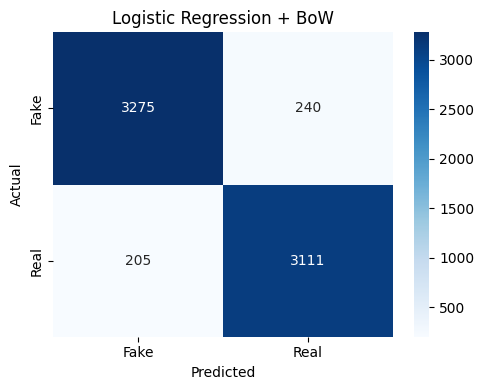


Random Forest + BoW  |  Macro F1: 0.9151
              precision    recall  f1-score   support

        Fake       0.91      0.92      0.92      3515
        Real       0.92      0.91      0.91      3316

    accuracy                           0.92      6831
   macro avg       0.92      0.91      0.92      6831
weighted avg       0.92      0.92      0.92      6831



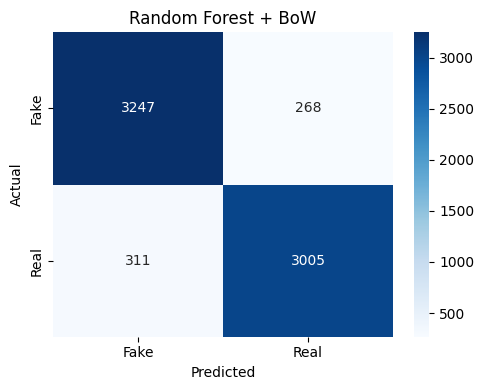


Naive Bayes + BoW  |  Macro F1: 0.9335
              precision    recall  f1-score   support

        Fake       0.93      0.94      0.94      3515
        Real       0.94      0.93      0.93      3316

    accuracy                           0.93      6831
   macro avg       0.93      0.93      0.93      6831
weighted avg       0.93      0.93      0.93      6831



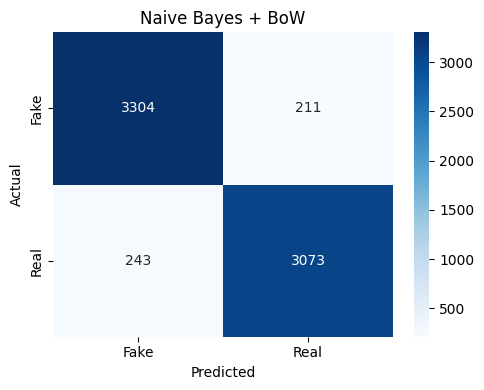


Logistic Regression + TF-IDF  |  Macro F1: 0.9349
              precision    recall  f1-score   support

        Fake       0.94      0.94      0.94      3515
        Real       0.93      0.93      0.93      3316

    accuracy                           0.94      6831
   macro avg       0.93      0.93      0.93      6831
weighted avg       0.94      0.94      0.94      6831



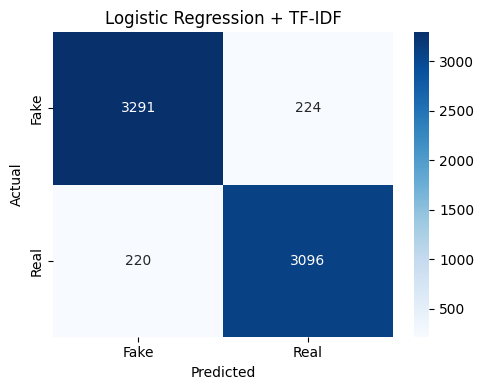


Random Forest + TF-IDF  |  Macro F1: 0.9196
              precision    recall  f1-score   support

        Fake       0.93      0.92      0.92      3515
        Real       0.91      0.92      0.92      3316

    accuracy                           0.92      6831
   macro avg       0.92      0.92      0.92      6831
weighted avg       0.92      0.92      0.92      6831



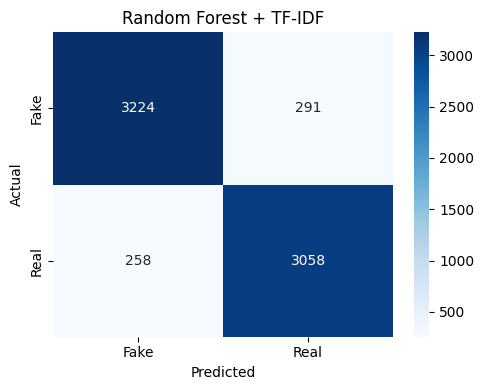


Naive Bayes + TF-IDF  |  Macro F1: 0.9301
              precision    recall  f1-score   support

        Fake       0.93      0.94      0.93      3515
        Real       0.94      0.92      0.93      3316

    accuracy                           0.93      6831
   macro avg       0.93      0.93      0.93      6831
weighted avg       0.93      0.93      0.93      6831



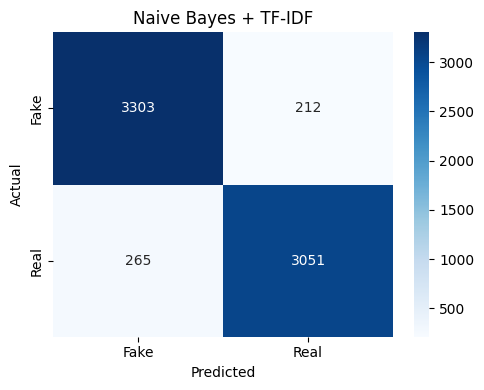


Logistic Regression + Word2Vec  |  Macro F1: 0.8981
              precision    recall  f1-score   support

        Fake       0.90      0.91      0.90      3515
        Real       0.90      0.89      0.89      3316

    accuracy                           0.90      6831
   macro avg       0.90      0.90      0.90      6831
weighted avg       0.90      0.90      0.90      6831



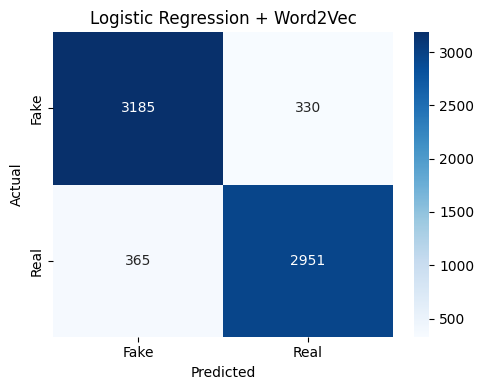


Random Forest + Word2Vec  |  Macro F1: 0.9097
              precision    recall  f1-score   support

        Fake       0.90      0.92      0.91      3515
        Real       0.92      0.90      0.91      3316

    accuracy                           0.91      6831
   macro avg       0.91      0.91      0.91      6831
weighted avg       0.91      0.91      0.91      6831



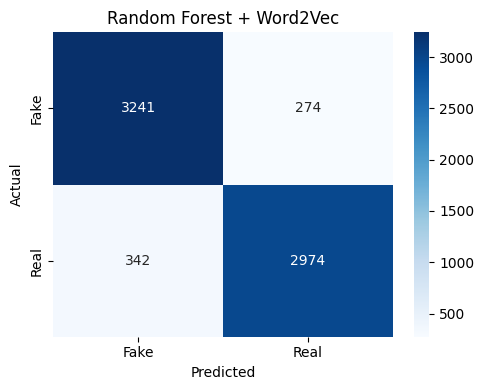


Naive Bayes + Word2Vec  |  Macro F1: 0.8628
              precision    recall  f1-score   support

        Fake       0.85      0.89      0.87      3515
        Real       0.88      0.84      0.86      3316

    accuracy                           0.86      6831
   macro avg       0.86      0.86      0.86      6831
weighted avg       0.86      0.86      0.86      6831



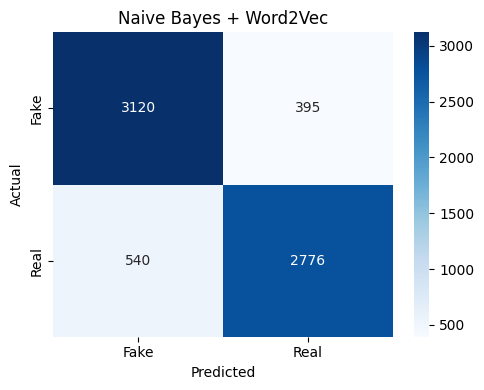


Logistic Regression + fastText  |  Macro F1: 0.9029
              precision    recall  f1-score   support

        Fake       0.91      0.91      0.91      3515
        Real       0.90      0.90      0.90      3316

    accuracy                           0.90      6831
   macro avg       0.90      0.90      0.90      6831
weighted avg       0.90      0.90      0.90      6831



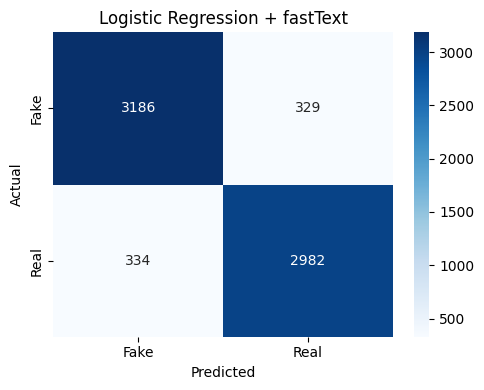


Random Forest + fastText  |  Macro F1: 0.8951
              precision    recall  f1-score   support

        Fake       0.90      0.89      0.90      3515
        Real       0.89      0.90      0.89      3316

    accuracy                           0.90      6831
   macro avg       0.90      0.90      0.90      6831
weighted avg       0.90      0.90      0.90      6831



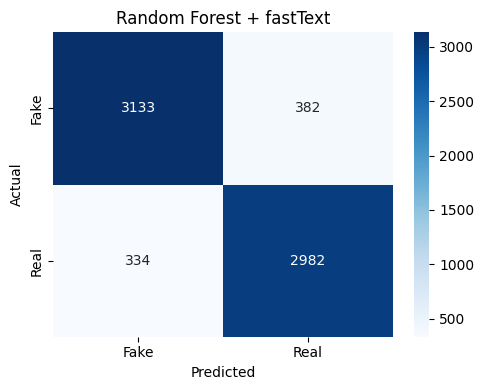


Naive Bayes + fastText  |  Macro F1: 0.8586
              precision    recall  f1-score   support

        Fake       0.88      0.84      0.86      3515
        Real       0.84      0.87      0.86      3316

    accuracy                           0.86      6831
   macro avg       0.86      0.86      0.86      6831
weighted avg       0.86      0.86      0.86      6831



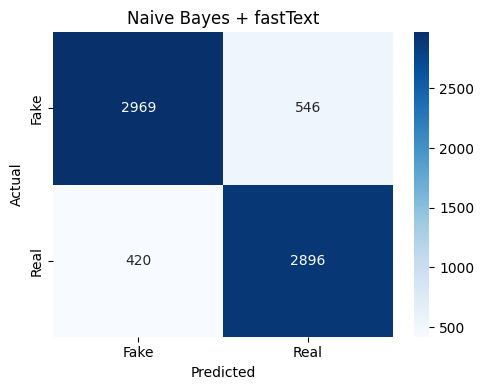


Logistic Regression + BERT  |  Macro F1: 0.9018
              precision    recall  f1-score   support

        Fake       0.90      0.90      0.90      3515
        Real       0.90      0.90      0.90      3316

    accuracy                           0.90      6831
   macro avg       0.90      0.90      0.90      6831
weighted avg       0.90      0.90      0.90      6831



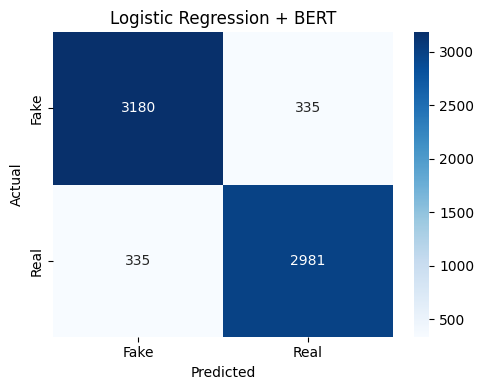


Random Forest + BERT  |  Macro F1: 0.8805
              precision    recall  f1-score   support

        Fake       0.89      0.88      0.88      3515
        Real       0.87      0.88      0.88      3316

    accuracy                           0.88      6831
   macro avg       0.88      0.88      0.88      6831
weighted avg       0.88      0.88      0.88      6831



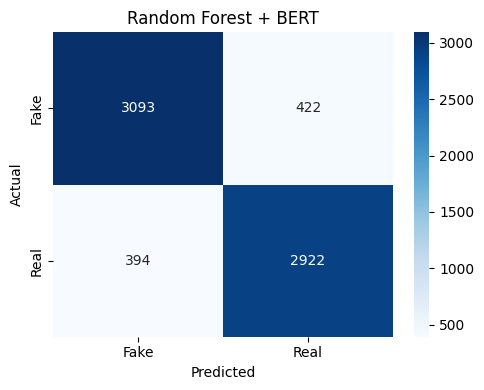


Naive Bayes + BERT  |  Macro F1: 0.8101
              precision    recall  f1-score   support

        Fake       0.82      0.81      0.82      3515
        Real       0.80      0.81      0.80      3316

    accuracy                           0.81      6831
   macro avg       0.81      0.81      0.81      6831
weighted avg       0.81      0.81      0.81      6831



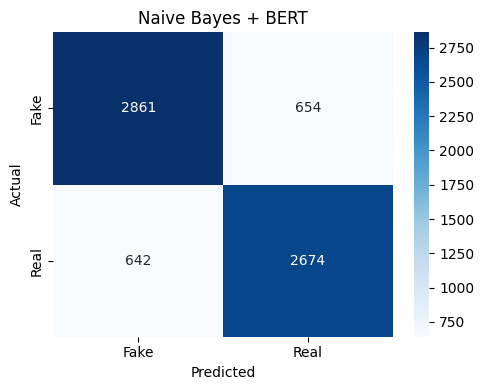

In [32]:
results = []
trained_models = {}

for feat_name, (X_tr, X_v, X_te) in features.items():
    classifiers = get_classifiers(feat_name)
    
    for clf_name, clf in classifiers.items():
        result = evaluate_model(clf, X_tr, y_train, X_v, y_val, clf_name, feat_name)
        trained_models[(feat_name, clf_name)] = clf
        results.append(result)

## 5. Evaluation Summary

In [33]:
results_df = pd.DataFrame(results).sort_values("Macro F1", ascending=False).reset_index(drop=True)
results_df.index += 1
results_df.index.name = "Rank"
print(results_df.to_string())

       Feature           Classifier  Macro F1
Rank                                         
1       TF-IDF  Logistic Regression    0.9349
2          BoW  Logistic Regression    0.9348
3          BoW          Naive Bayes    0.9335
4       TF-IDF          Naive Bayes    0.9301
5       TF-IDF        Random Forest    0.9196
6          BoW        Random Forest    0.9151
7     Word2Vec        Random Forest    0.9097
8     fastText  Logistic Regression    0.9029
9         BERT  Logistic Regression    0.9018
10    Word2Vec  Logistic Regression    0.8981
11    fastText        Random Forest    0.8951
12        BERT        Random Forest    0.8805
13    Word2Vec          Naive Bayes    0.8628
14    fastText          Naive Bayes    0.8586
15        BERT          Naive Bayes    0.8101


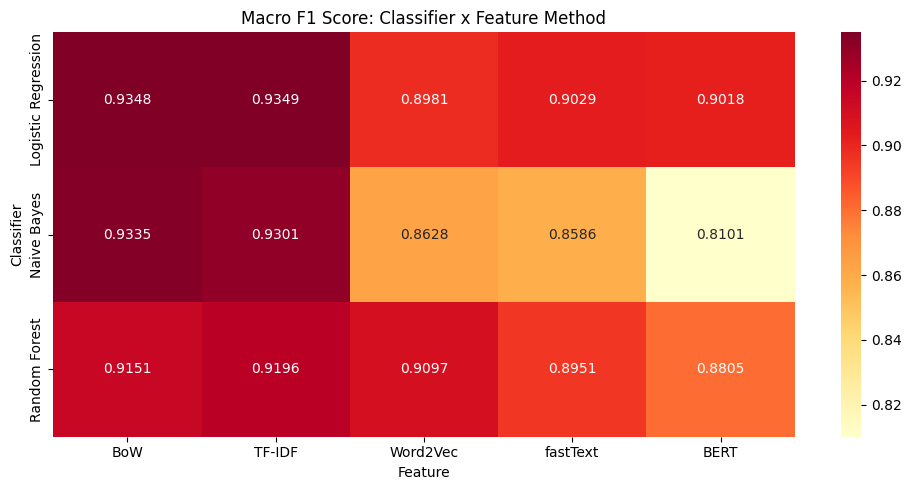


Best combination: Logistic Regression + TF-IDF (Macro F1: 0.9349)


In [34]:
# Heatmap of F1 scores: Classifier x Feature
pivot = results_df.pivot_table(index="Classifier", columns="Feature", values="Macro F1")
pivot = pivot[["BoW", "TF-IDF", "Word2Vec", "fastText", "BERT"]]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlOrRd", ax=ax)
ax.set_title("Macro F1 Score: Classifier x Feature Method")
plt.tight_layout()
plt.show()

best = results_df.iloc[0]
print(f"\nBest combination: {best['Classifier']} + {best['Feature']} (Macro F1: {best['Macro F1']:.4f})")

## 6. Test Set Predictions

Using the best-performing model to generate predictions for the test set.

In [36]:
best_feat = results_df.iloc[0]["Feature"]
best_clf_name = results_df.iloc[0]["Classifier"]
best_model = trained_models[(best_feat, best_clf_name)]

# Predict on test features (in shuffled order)
X_test_final = features[best_feat][2]
test_predictions = best_model.predict(X_test_final)

# Recover original file order
df_test_orig = pd.read_csv(
    "data/raw/testing_data.csv",
    header=None,
    sep='\t',
    names=['is_real', 'text']
)
shuffled_indices = df_test_orig.sample(frac=1, random_state=RANDOM_STATE).index.values
original_preds = np.empty(len(test_predictions), dtype=int)
original_preds[shuffled_indices] = test_predictions

# Save predictions in original format
df_test_orig["is_real"] = original_preds
df_test_orig.to_csv(
    "data/processed/testing_data_predicted.csv",
    sep="\t",
    header=False,
    index=False
)

print(f"Predictions saved to data/processed/testing_data_predicted.csv")
print(f"Using: {best_clf_name} + {best_feat}")
print(f"\nPredicted label distribution:")
print(pd.Series(original_preds).value_counts().sort_index())

Predictions saved to data/processed/testing_data_predicted.csv
Using: Logistic Regression + TF-IDF

Predicted label distribution:
0    4849
1    5135
Name: count, dtype: int64


In [37]:
df_verify = pd.read_csv(
    "data/processed/testing_data_predicted.csv",
    header=None,
    sep="\t",
    names=["is_real", "text"]
)
print(f"Shape: {df_verify.shape}")
print(f"Labels: {sorted(df_verify['is_real'].unique())}")
print(f"\nSample predictions:")
df_verify.head(10)

Shape: (9984, 2)
Labels: [np.int64(0), np.int64(1)]

Sample predictions:


,is_real,text
0,0,copycat muslim terrorist arrested with assault...
1,0,wow! chicago protester caught on camera admits...
2,1,germany's fdp look to fill schaeuble's big shoes
3,0,mi school sends welcome back packet warning ki...
4,1,u.n. seeks 'massive' aid boost amid rohingya '...
5,0,did oprah just leave ‚nasty‚ hillary wishing s...
6,1,france's macron says his job not 'cool' cites ...
7,0,flashback: chilling ‚60 minutes‚ interview wit...
8,1,spanish foreign ministry says to expel north k...
9,1,trump says cuba 'did some bad things' aimed at...
